<a href="https://colab.research.google.com/github/KayotPoziloy/eeg_studies/blob/main/%D1%8D%D1%8D%D0%B32.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Команда "Нейроштучки":** Гурская Юлия P3420, Яхонтов Максим P3420, Фархутдинов Айдар P3420.

Цель работы:
1. Собрать и подключиться установку для измерения бэта-волн
2. Произвести следующие замеры по 5 минут каждый:
	1. закрытые глаза, рок музыка
	2. закрытые глаза и воспроизведение в голове путь от учебы до дома
	3. глаза открыты и рещение iq тестов
	4. глаза открыты и решение алгоритмических задач по программированию
	5. глаза открыты и игра в шахматы
	6. глаза открыты и игра в CS2
3. Обработать полученные данные
4. Построить графики и проанализировать
5. Сформулировать гипотезы и вывод

**ЭЭГ (электроэнцефалография)** — метод регистрации биоэлектрической активности мозга с помощью электродов, расположенных на коже головы.

### **Основные ритмы ЭЭГ**

**Delta (δ)**: 0.5–4 Гц, сон.

**Theta (θ)**: 4–8 Гц, расслабленность, дремота.

**Alpha (α)**: 8–13 Гц, состояние спокойного бодрствования, особенно при закрытых глазах.

**Beta (β)**: 13–30 Гц, активность, внимание, стресс.

**Gamma (γ)**: >30 Гц, когнитивные процессы.


### **Бета-ритмы**

Наиболее выражены в лобной области при активности, внимании, решении задач и стрессе.

### **Предположения**

При активных задачах (3-6) ожидается усиление мощности в диапазоне бета.
При пассивных состояниях (1-2) ожидается снижение мощности бета-ритмов.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, welch, hilbert

# **Предобработка данных**

In [ ]:
file_paths = [
    "/content/1_A0.csv",
    "/content/2_A0.csv",
    "/content/3_A0.csv",
    "/content/4_A0.csv",
    "/content/5_A0.csv",
    "/content/6_A0.csv"
]

In [ ]:
# Считываем данные
# Создаем словарь для хранения данных
dataframes = {}

# Функция для проверки файла
def get_data(file_path):
    try:
        # Загружаем файл (предполагаем, что разделитель - точка с запятой)
        df = pd.read_csv(file_path, sep = ';')
        return df
    except Exception as e:
        print(f"Ошибка при загрузке файла {file_path}: {e}")
        return None

for i, path in enumerate(file_paths, 1):
    df = get_data(path)
    if df is not None:
        # Сохраняем dataframe
        dataframes[path] = df
# Пример доступа к данным
if len(dataframes) > 0:
    first_key = list(dataframes.keys())[0]
    print(f"\nПример данных из первого файла ({first_key}):")
    print(dataframes[first_key].head())
    print(f"\nТипы данных:")
    print(dataframes[first_key].dtypes)



Пример данных из первого файла (/content/1_A0.csv):
   1.22453201  \t2.49019599
0    1.224532      2.509804
1    1.236853      2.509804
2    1.236853      2.529412
3    1.236853      2.529412
4    1.236853      2.509804

Типы данных:
1.22453201      float64
\t2.49019599    float64
dtype: object


In [ ]:
# Создаем словарь для проверки пропусков в данных
missing_info = {}

# Функция для проверки файла
def check_file_for_missing(df):
  total_missing = df.isnull().sum().sum()
  missing_per_column = df.isnull().sum()
  return total_missing, missing_per_column

# Проверяем все файлы
print("Проверка файлов на пропуски данных:\n")
print("=" * 60)
i = 0
for path, df in dataframes.items():
    i += 1
    total_missing, missing_per_col = check_file_for_missing(df)
    missing_info[path] = {
            'total_missing': total_missing,
            'missing_per_column': missing_per_col,
            'shape': df.shape,
            'columns': df.columns.tolist()
        }
    # Выводим информацию
    exercise_num = i  # Получаем номер упражнения

    print(f"Файл {i}: {exercise_num} упр")
    print(f"  Размер данных: {df.shape}")
    print(f"  Всего пропущенных значений: {total_missing}")

    if total_missing > 0:
        print("  Пропуски по столбцам:")
        for col, missing_count in missing_per_col.items():
          if missing_count > 0:
            print(f"    - {col}: {missing_count} пропусков")
          else:
            print("  ✓ Пропусков нет!")
        print("-" * 40)



Проверка файлов на пропуски данных:

Файл 1: 1 упр
  Размер данных: (102373, 2)
  Всего пропущенных значений: 0
Файл 2: 2 упр
  Размер данных: (100408, 2)
  Всего пропущенных значений: 0
Файл 3: 3 упр
  Размер данных: (99716, 2)
  Всего пропущенных значений: 0
Файл 4: 4 упр
  Размер данных: (101473, 2)
  Всего пропущенных значений: 0
Файл 5: 5 упр
  Размер данных: (111864, 2)
  Всего пропущенных значений: 0
Файл 6: 6 упр
  Размер данных: (101141, 2)
  Всего пропущенных значений: 0


In [ ]:
# Переименовываем столбцы во всех датафреймах
for path, df in dataframes.items():
    # Проверяем количество столбцов
    if len(df.columns) >= 2:
        # Переименовываем первые два столбца
        new_columns = ['time', 'voltage']
        df.columns = new_columns
    else:
        print(f"В файле {path} меньше 2 столбцов")

In [ ]:
# Для каждого датафрейма устанавливаем первую точку времени как 0
for path, df in dataframes.items():
    if 'time' in df.columns and len(df) > 0:
        # Находим первое значение времени
        first_time = df['time'].iloc[0]
        # Вычитаем его из всего столбца времени
        df['time'] = (df['time'] - first_time)

# Проверим результат на примере первого файла
df1 = dataframes['/content/1_A0.csv']
print("Время после нормализации (первая точка = 0):")
print(df1['time'].head(10))

Время после нормализации (первая точка = 0):
0    0.000000
1    0.012321
2    0.012321
3    0.012321
4    0.012321
5    0.024609
6    0.024609
7    0.024609
8    0.024609
9    0.037061
Name: time, dtype: float64


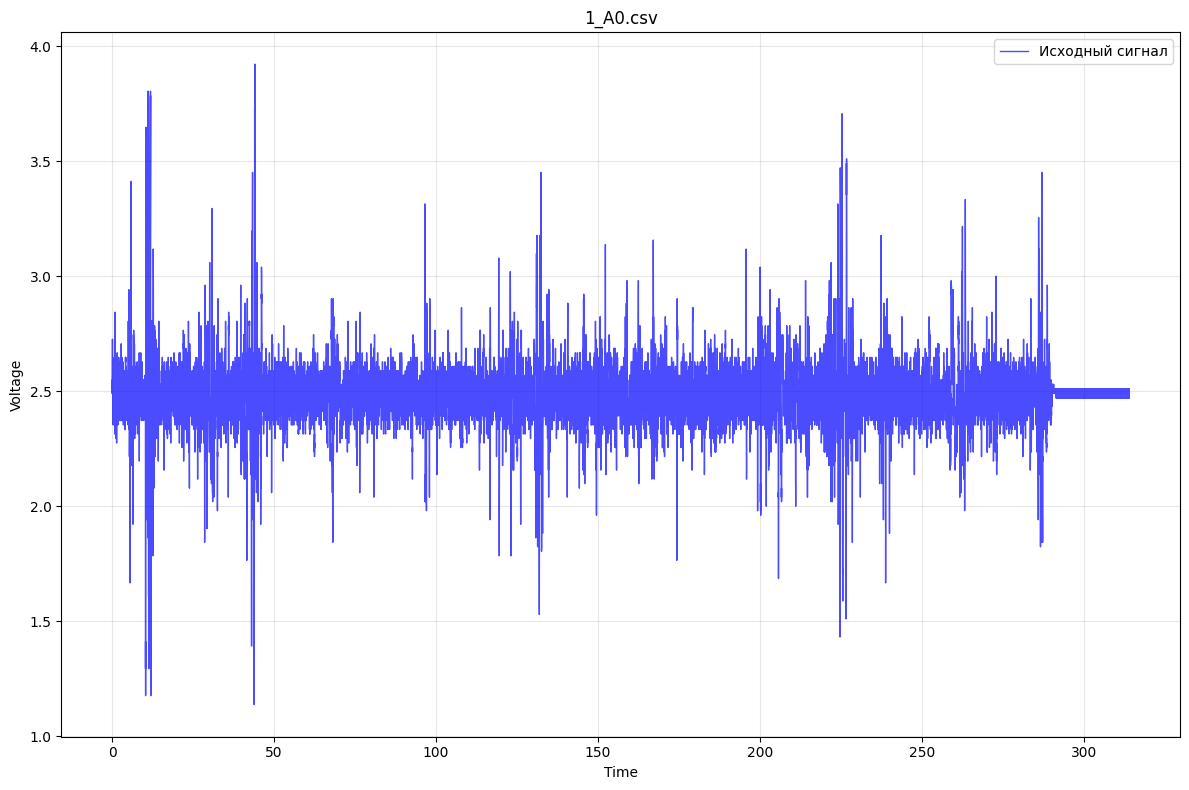

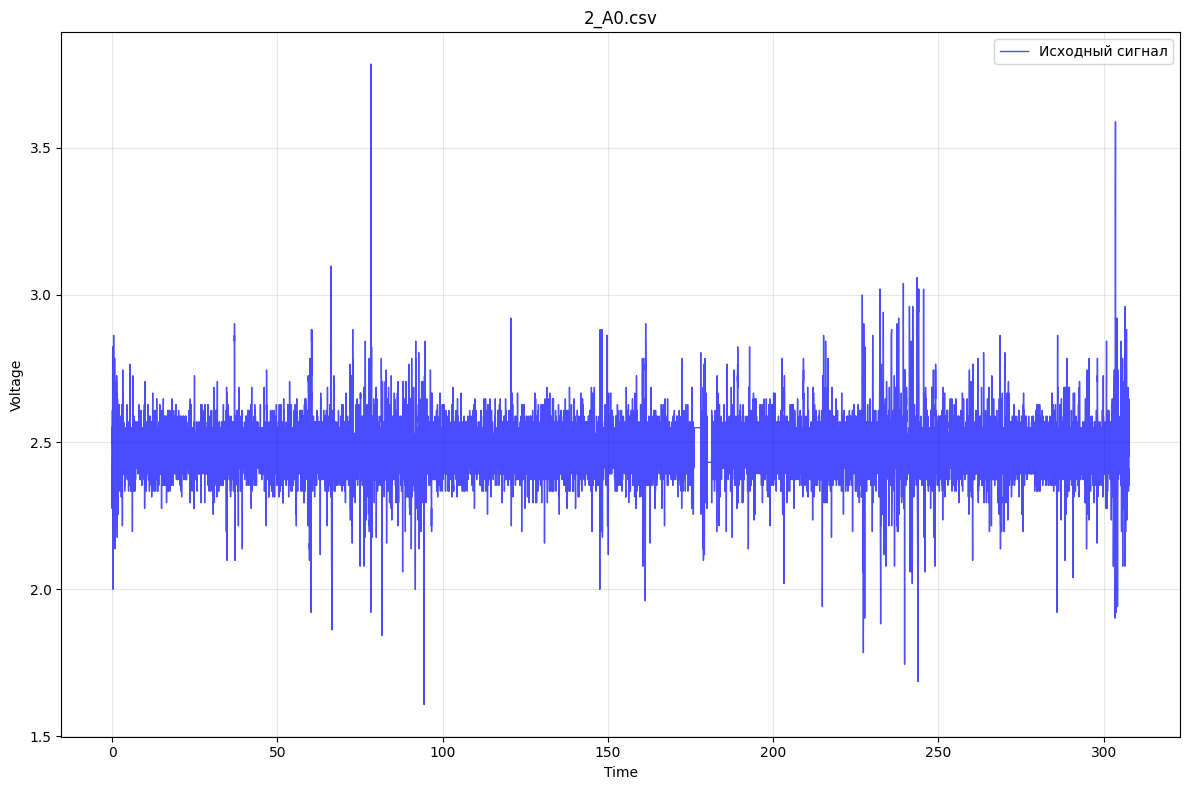

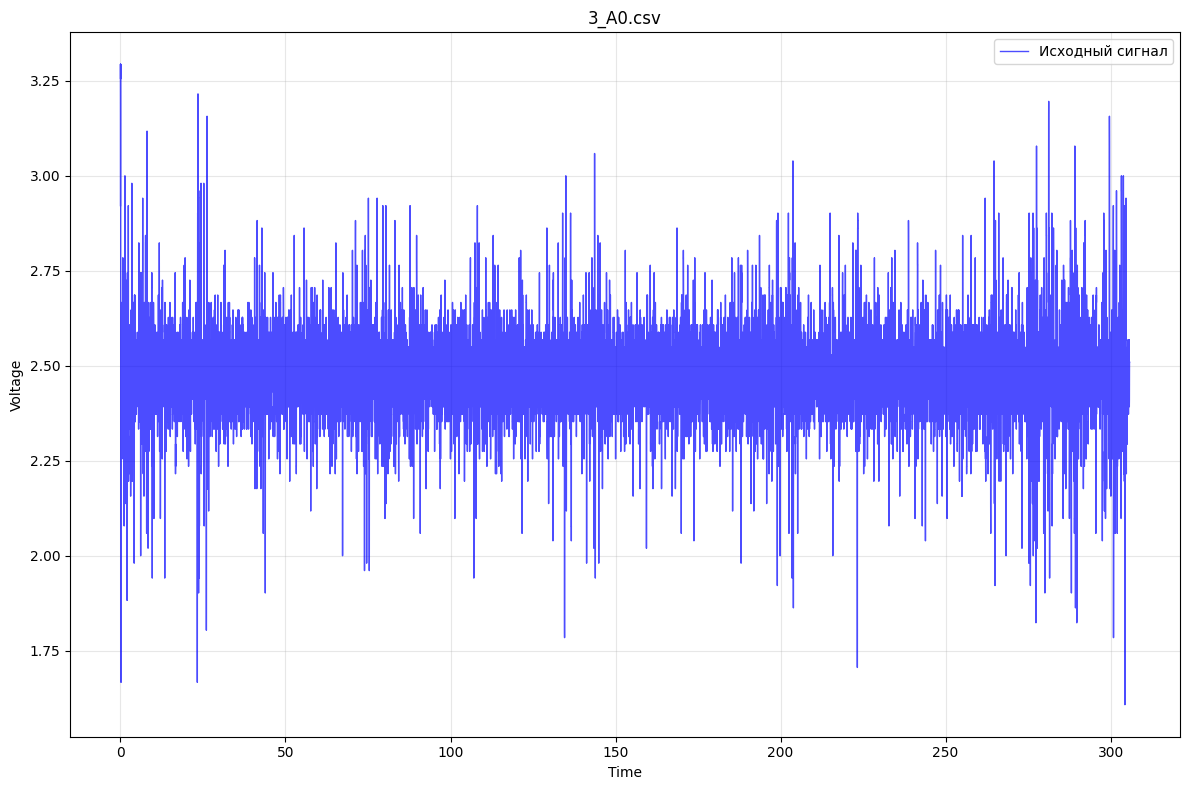

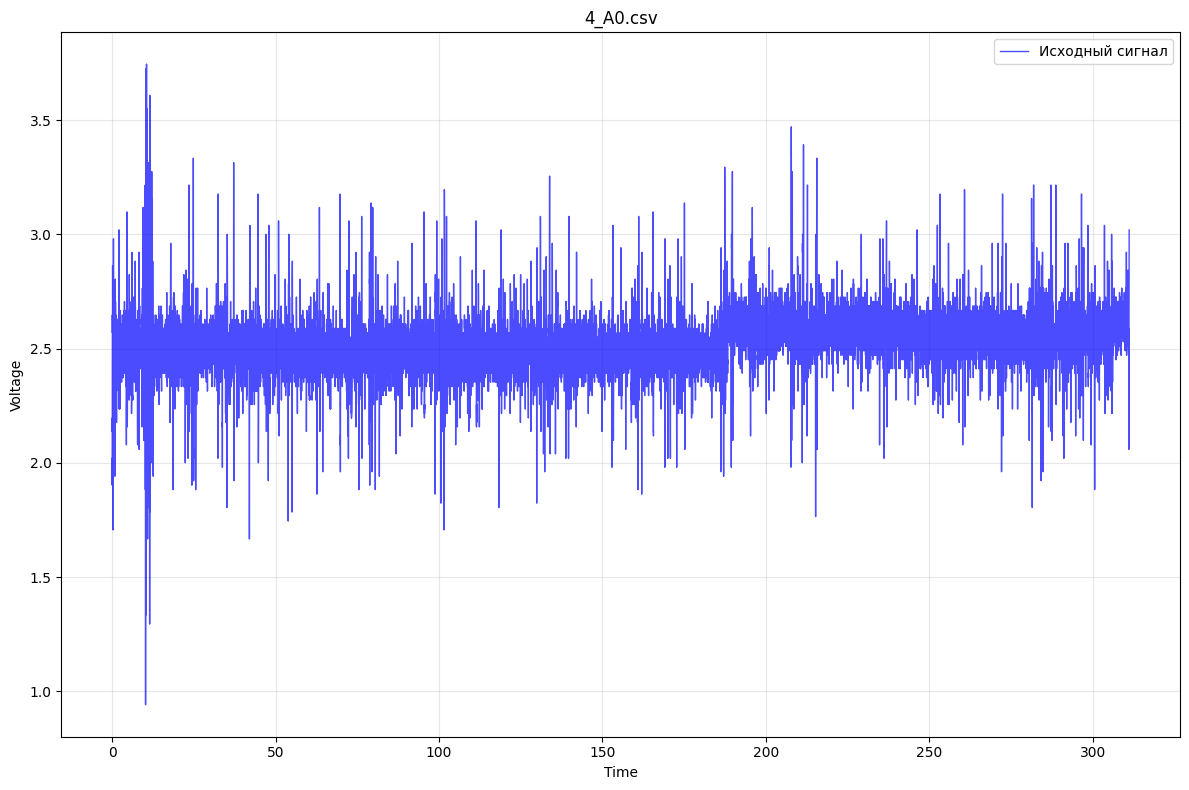

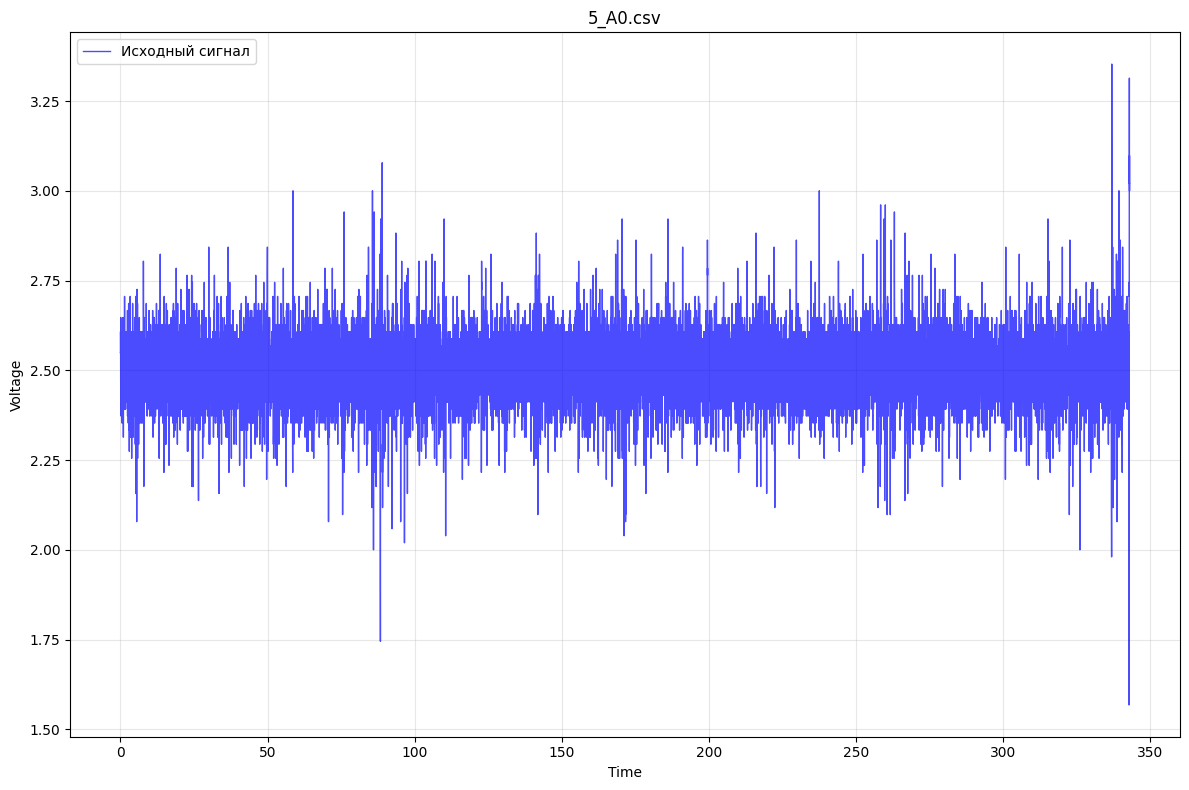

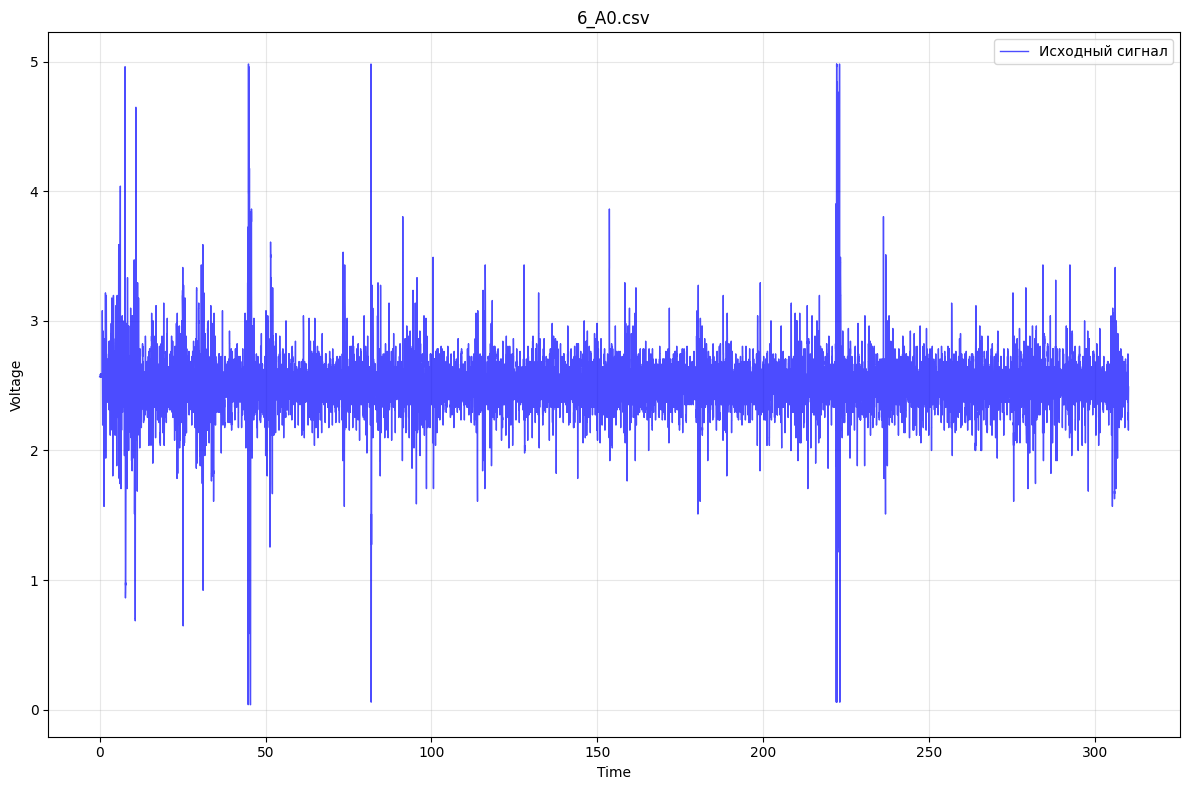

In [ ]:
# Визуализация исходных данных (с учетом проверки пропусков, подписания столбцов)
for path, df in dataframes.items():
    filename = path.split('/')[-1]
    if 'voltage' not in df.columns:
        print(f"В файле {filename} нет столбца voltage")
        continue

    plt.figure(figsize=(12, 8))
    plt.plot(df['time'], df['voltage'], 'blue', alpha=0.7, label='Исходный сигнал', linewidth=1)
    plt.title(f'{filename}')
    plt.xlabel('Time')
    plt.ylabel('Voltage')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

Построим график для 10-секундного фрагмента каждой записи

Длительность записи: 313.90031539999995 секунд
Середина: 156.95015769999998 секунд


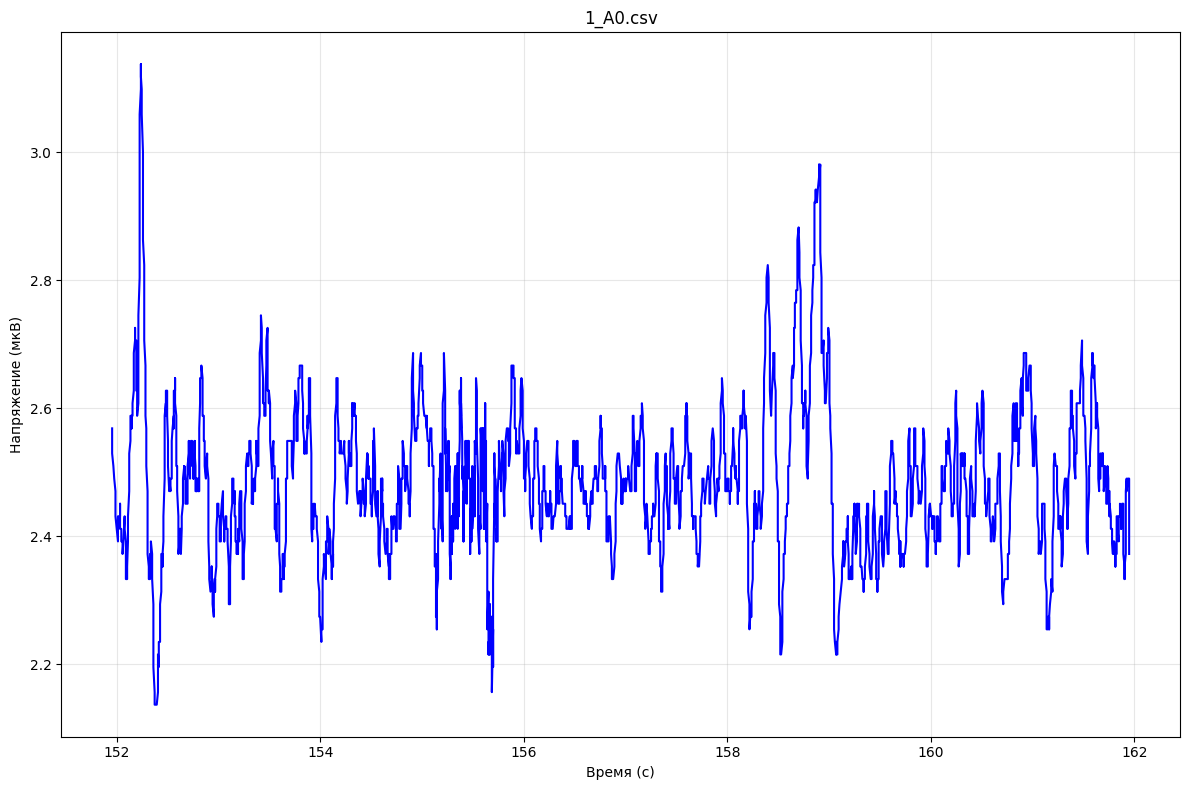

Длительность записи: 307.73921967 секунд
Середина: 153.869609835 секунд


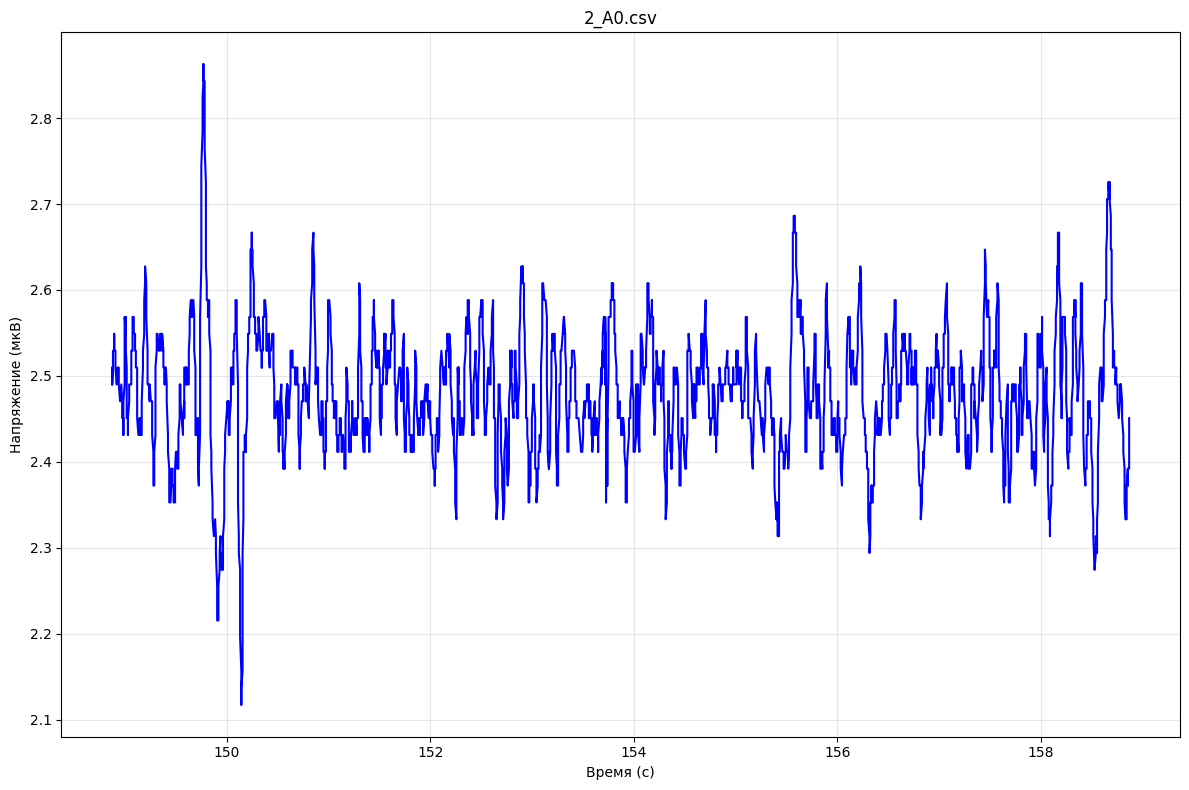

Длительность записи: 305.75206184999996 секунд
Середина: 152.87603092499998 секунд


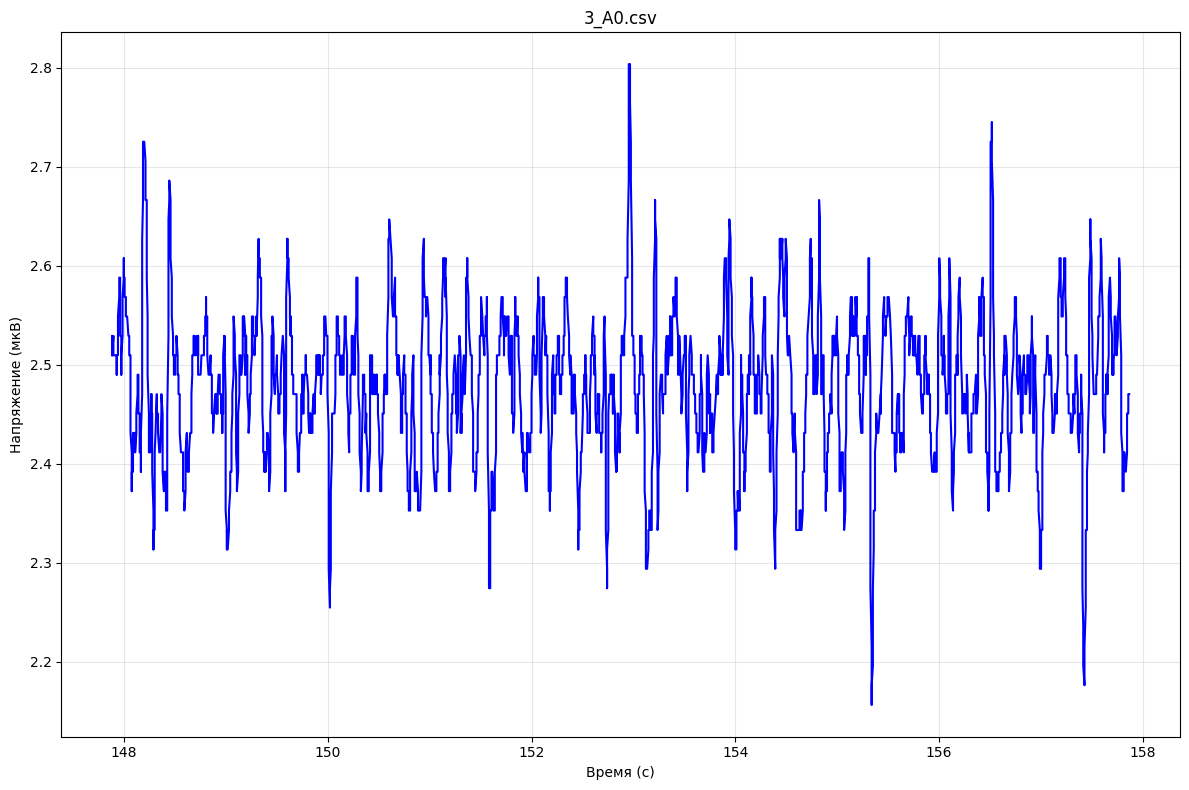

Длительность записи: 311.09796047 секунд
Середина: 155.548980235 секунд


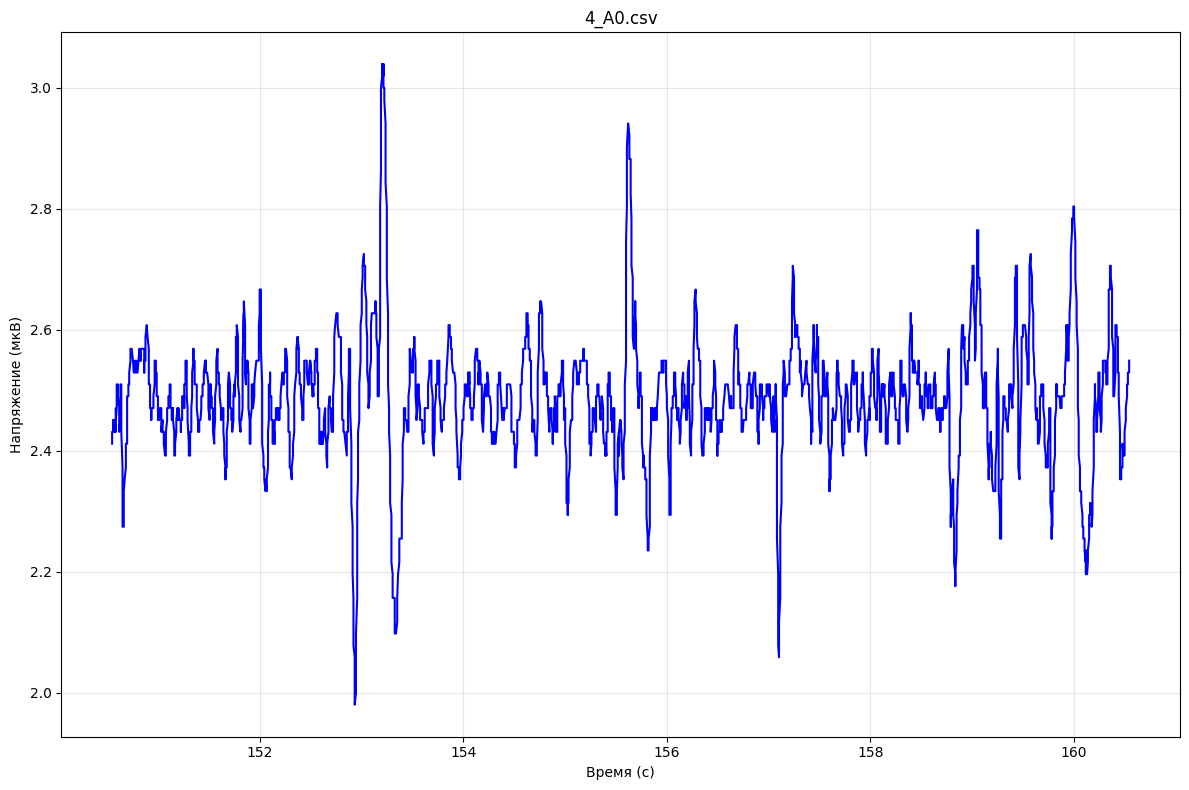

Длительность записи: 342.91928339 секунд
Середина: 171.459641695 секунд


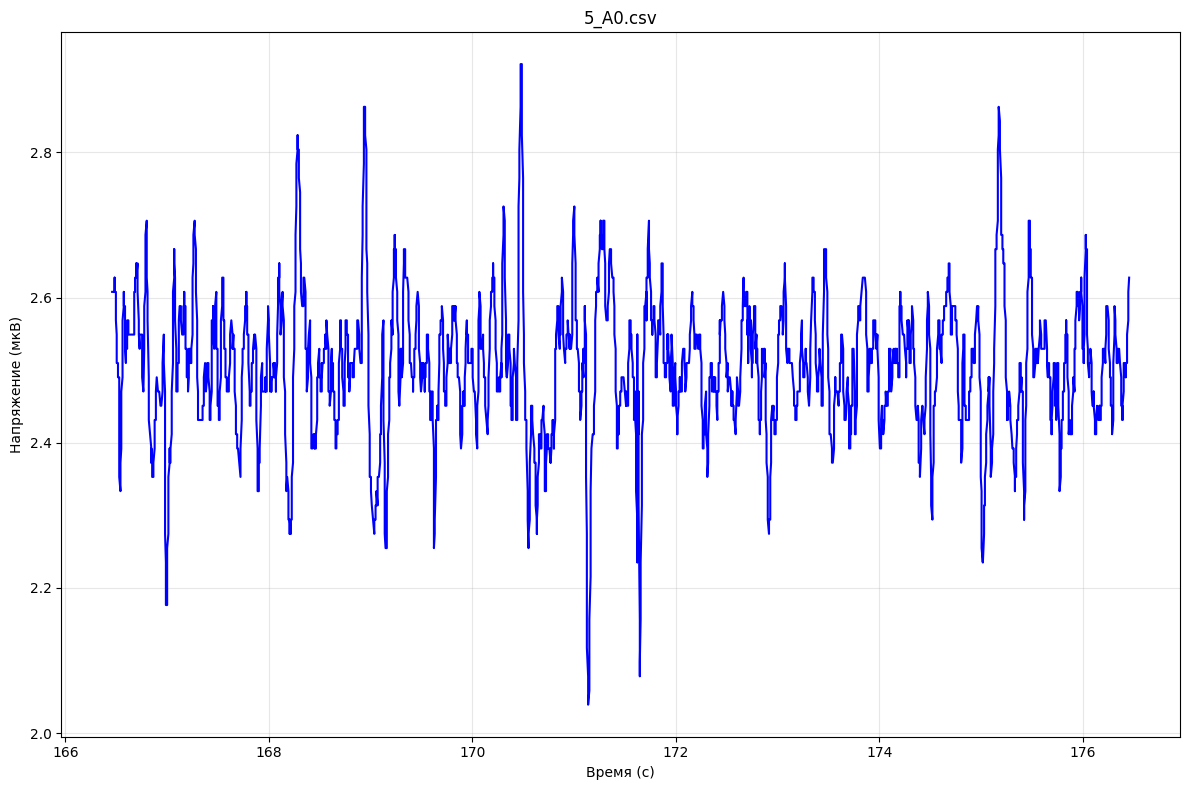

Длительность записи: 310.04090309000003 секунд
Середина: 155.02045154500001 секунд


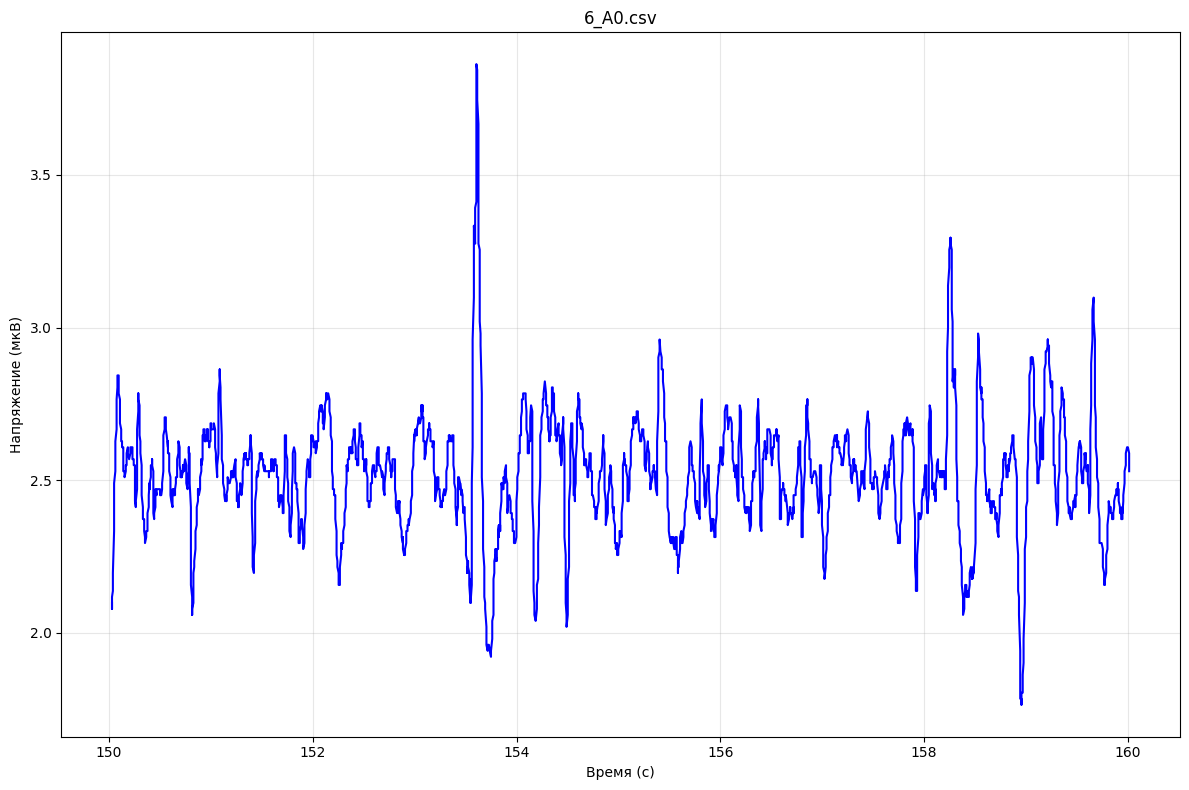

In [ ]:
for path, df in dataframes.items():
  filename = path.split('/')[-1]

  # Общая длительность записи
  total_time = df['time'].iloc[-1]
  print("Длительность записи:", total_time, "секунд")

  # Время середины
  mid_time = total_time / 2
  print("Середина:", mid_time, "секунд")

  # Берем 10 секунд вокруг середины
  start = mid_time - 5
  end = mid_time + 5
  fragment = df[(df['time'] >= start) & (df['time'] <= end)]

  plt.figure(figsize=(12, 8))
  plt.plot(fragment['time'], fragment['voltage'], color='blue')
  plt.title(f'{filename}')
  plt.xlabel("Время (с)")
  plt.ylabel("Напряжение (мкВ)")
  plt.grid(alpha=0.3)
  plt.tight_layout()
  plt.show()



### Фильтрация

1. Полосовой фильтр:
- Нижняя граница 1 Гц:
    Убираем низкочастотный дрейф (0–0.5 Гц), вызванный: дрейфом электрода, дыханием, движением головы.

- Верхняя граница 40 Гц:
    Убираем высокочастотные шумы (>40–50 Гц), вызванные: электросетью (50/60 Гц), мышечными артефактами, наушниками и другими источниками шума.


2. Бета-фильтр:
- 13-30гц - стандартный диапазон бета-ритмов. Цель: выделить только бета

3. Гильберт-преобразование
- Этот фильтр помогает увидеть временную динамику силы бета-ритма

4. Скользящая мощность
- 0.5 с — стандартное окно для когнитивных ЭЭГ исследований (достаточно короткое, чтобы отследить динамику). Дает сглаженную мощность бета-ритма

1_A0.csv: Fs = 326.13 Гц


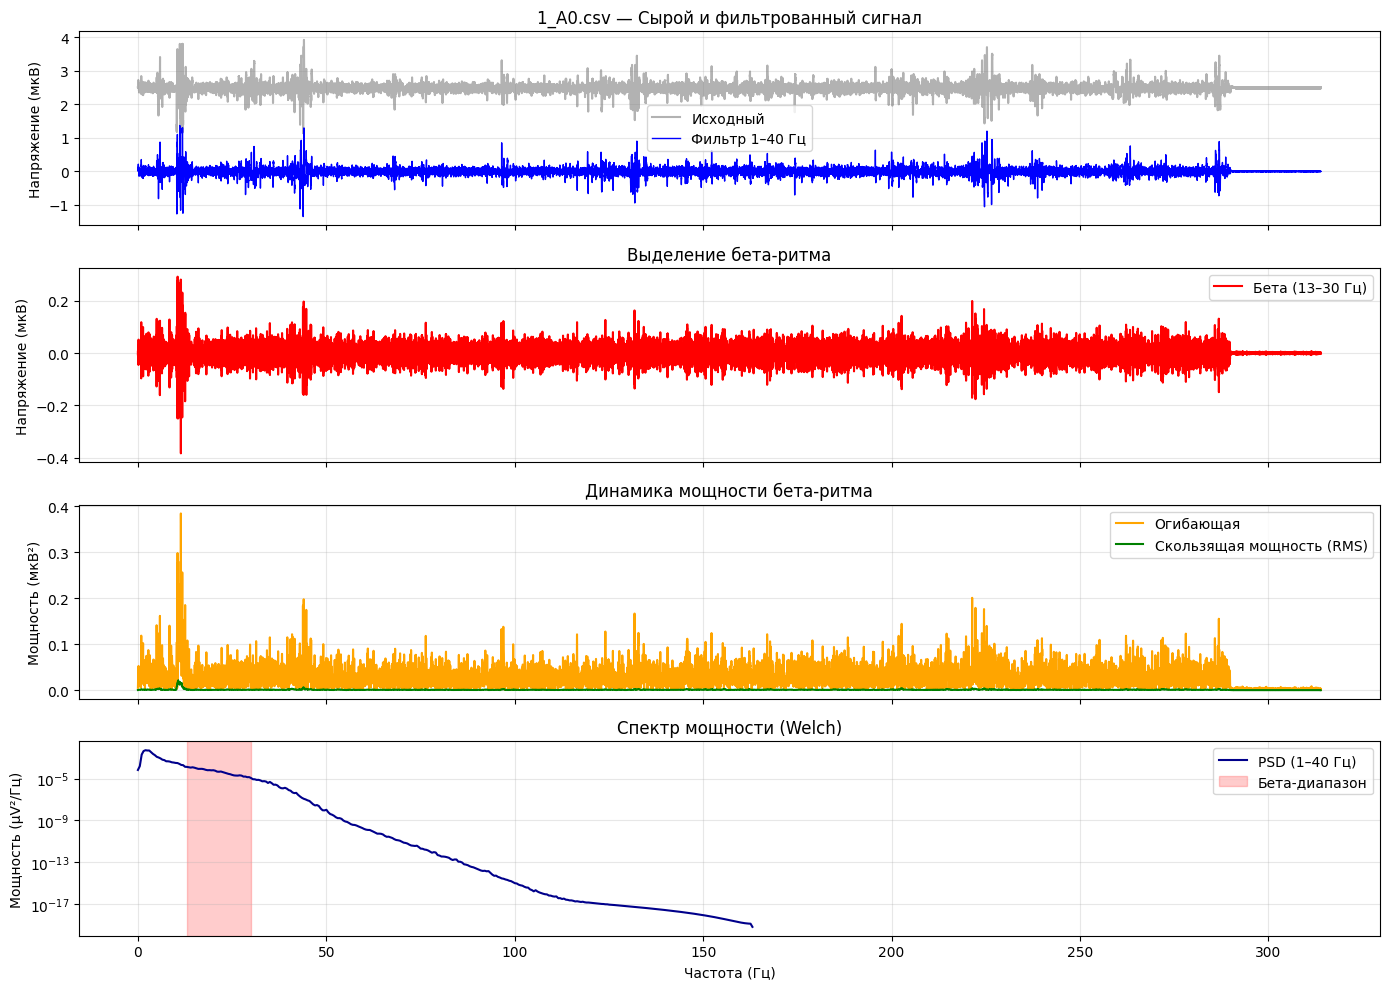

/tmp/ipython-input-722512952.py:85: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  alpha_power = np.trapz(psd[alpha_idx], freqs[alpha_idx])
/tmp/ipython-input-722512952.py:86: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  beta_power_total  = np.trapz(psd[beta_idx], freqs[beta_idx])


2_A0.csv: Fs = 326.27 Гц


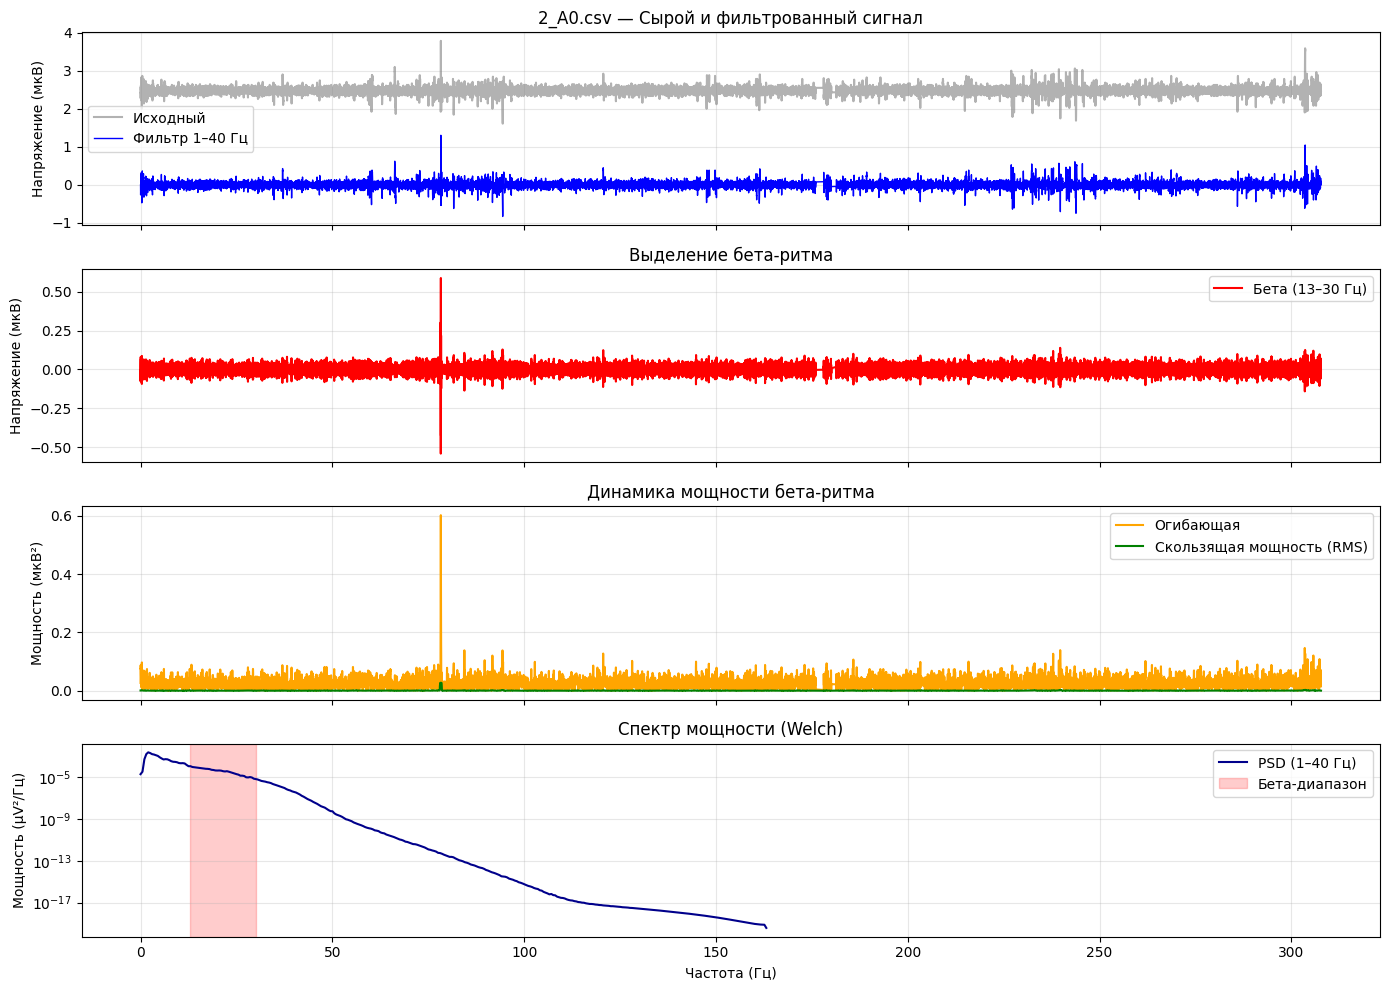

3_A0.csv: Fs = 326.13 Гц


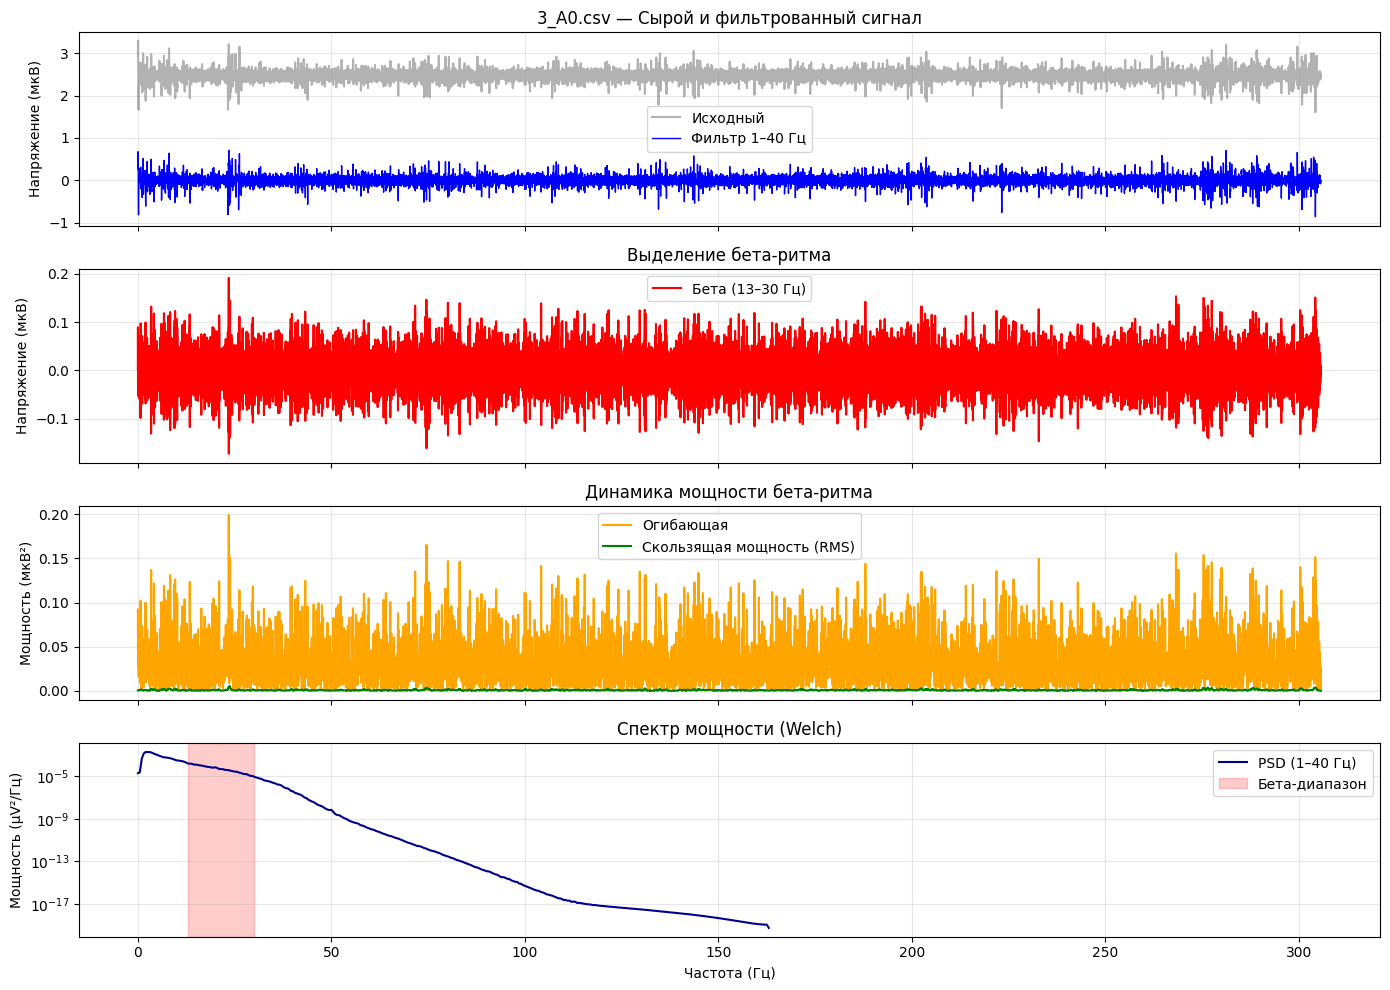

4_A0.csv: Fs = 326.17 Гц


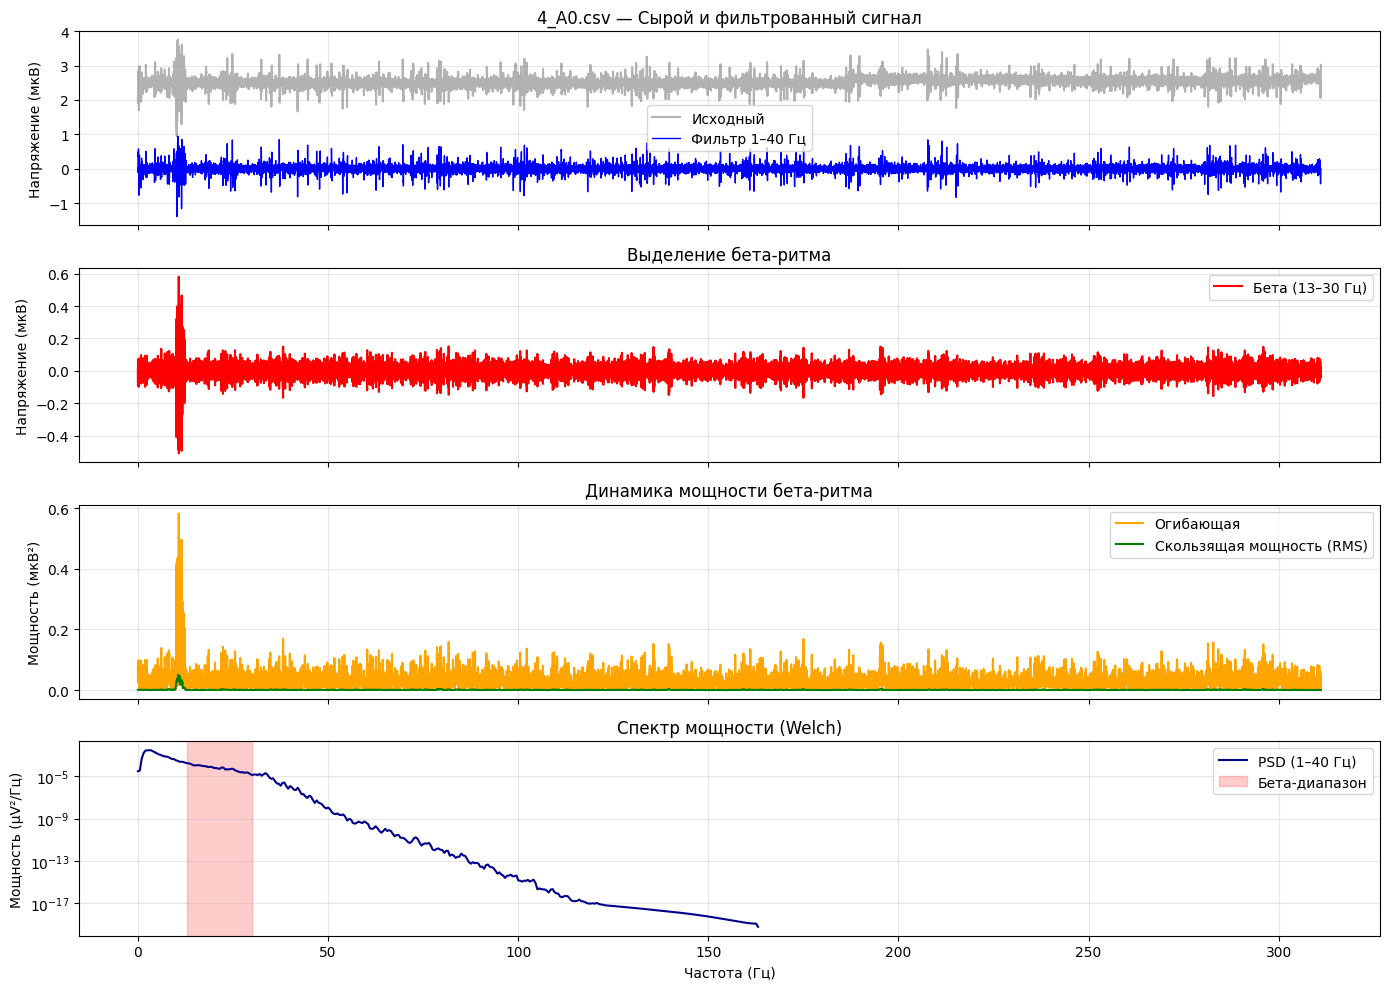

5_A0.csv: Fs = 326.21 Гц


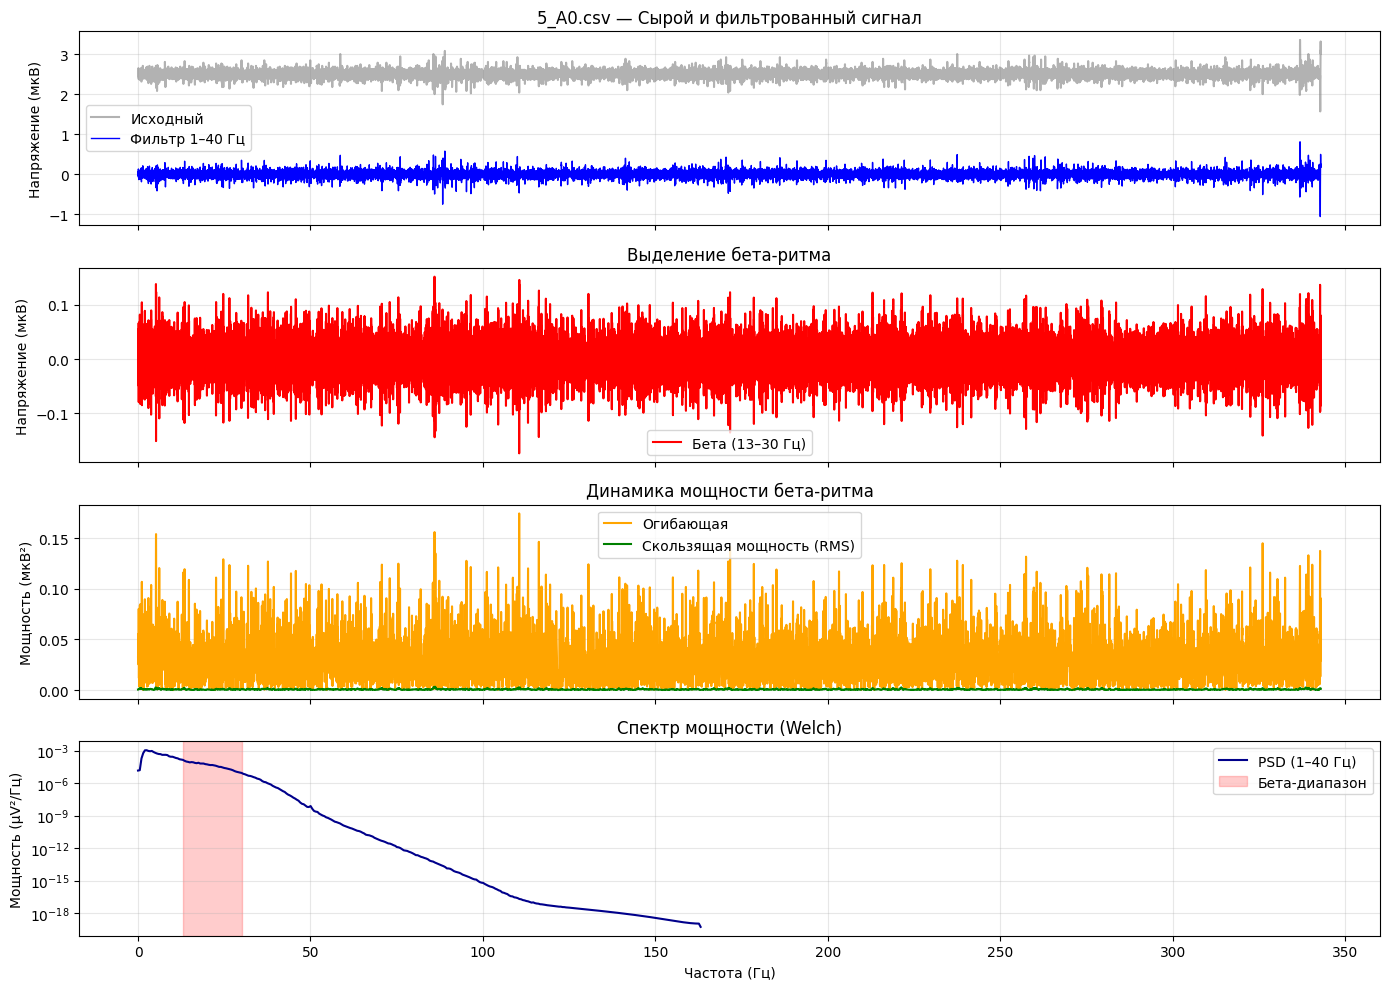

6_A0.csv: Fs = 326.22 Гц


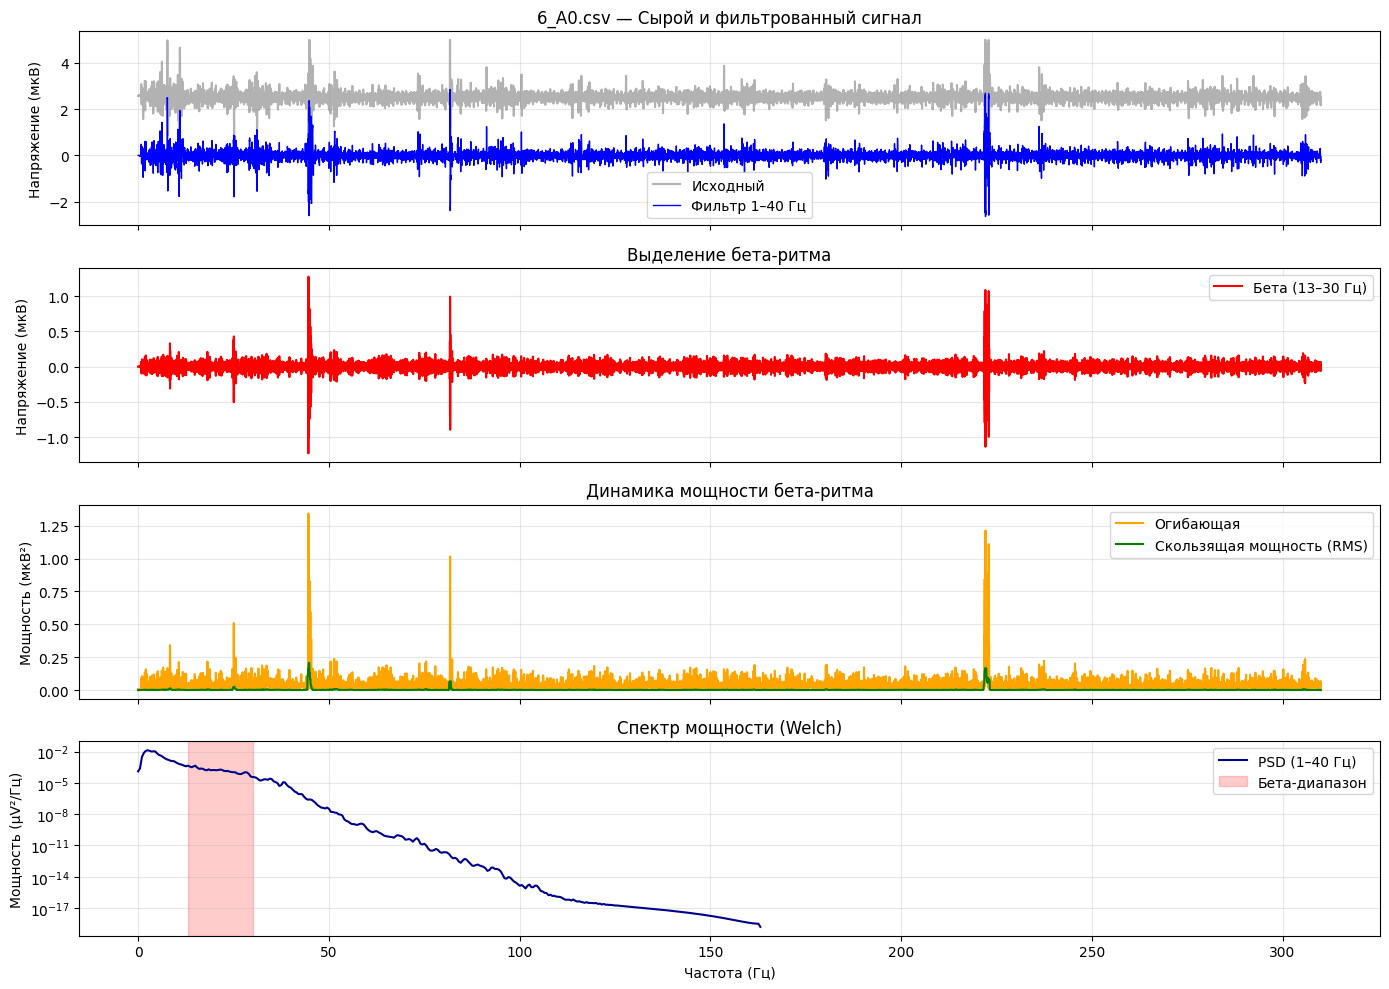

       Файл  Alpha (8–13 Гц)  Beta (13–30 Гц)
0  1_A0.csv           0.0013           0.0009
1  2_A0.csv           0.0010           0.0007
2  3_A0.csv           0.0015           0.0010
3  4_A0.csv           0.0016           0.0012
4  5_A0.csv           0.0012           0.0008
5  6_A0.csv           0.0039           0.0029


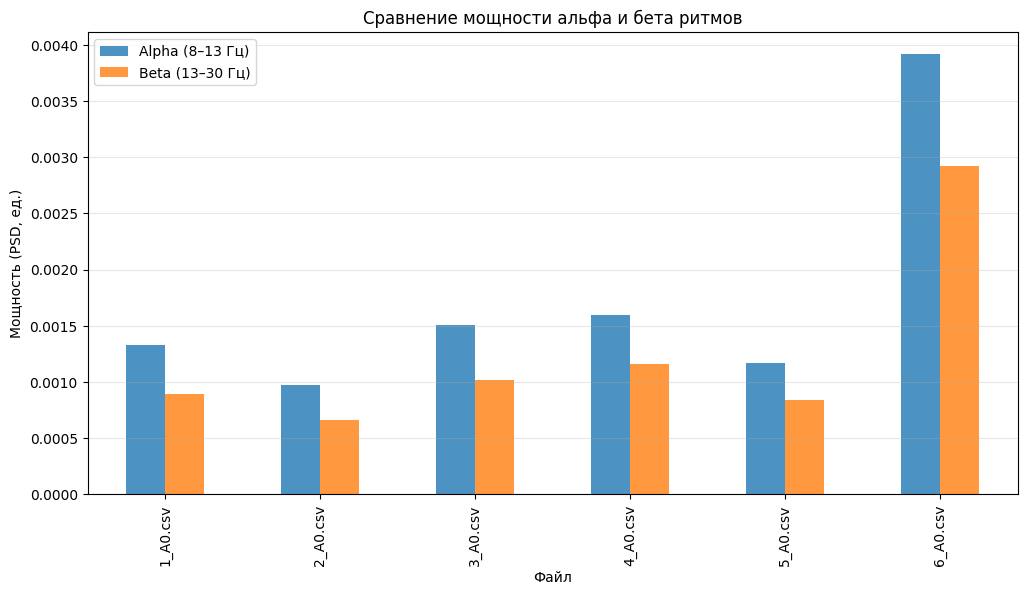

In [ ]:

# Фильтры
def bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

def beta_filter(data, fs, low=13, high=30, order=4):
    nyq = 0.5 * fs
    low /= nyq
    high /= nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

def moving_average_power(signal, window_size):
    squared = signal ** 2
    return np.convolve(squared, np.ones(window_size)/window_size, mode='same')

# Основной анализ
results = []

for path, df in dataframes.items():
    filename = path.split("/")[-1]

    # Частота дискретизации
    dt = np.mean(np.diff(df['time']))
    fs = 1 / dt
    print(f"{filename}: Fs = {fs:.2f} Гц")

    # Фильтрация
    raw = df['voltage'].values
    sig = bandpass_filter(raw, 1, 40, fs)
    sig_beta = beta_filter(sig, fs)

    # Огибающая (Гильберт)
    analytic_signal = hilbert(sig_beta)
    envelope = np.abs(analytic_signal)

    # Скользящее окно мощности (0.5 c)
    window_size = int(fs * 0.5)
    beta_power = moving_average_power(sig_beta, window_size)

    # PSD (мощность по частотам)
    freqs, psd = welch(sig, fs, nperseg=int(fs*2))

    # --- Визуализация ---
    fig, axs = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

    # 1. Сырой и фильтрованный сигнал
    axs[0].plot(df['time'], raw, color="gray", alpha=0.6, label="Исходный")
    axs[0].plot(df['time'], sig, color="blue", lw=1, label="Фильтр 1–40 Гц")
    axs[0].set_title(f"{filename} — Сырой и фильтрованный сигнал")
    axs[0].set_ylabel("Напряжение (мкВ)")
    axs[0].legend(); axs[0].grid(alpha=0.3)

    # 2. Бета-сигнал
    axs[1].plot(df['time'], sig_beta, color="red", label="Бета (13–30 Гц)")
    axs[1].set_title("Выделение бета-ритма")
    axs[1].set_ylabel("Напряжение (мкВ)")
    axs[1].legend(); axs[1].grid(alpha=0.3)

    # 3. Огибающая и скользящая мощность
    axs[2].plot(df['time'], envelope, color="orange", label="Огибающая")
    axs[2].plot(df['time'], beta_power, color="green", label="Скользящая мощность (RMS)")
    axs[2].set_title("Динамика мощности бета-ритма")
    axs[2].set_ylabel("Мощность (мкВ²)")
    axs[2].legend(); axs[2].grid(alpha=0.3)

    # 4. PSD (спектр мощности)
    axs[3].semilogy(freqs, psd, color="darkblue", label="PSD (1–40 Гц)")
    axs[3].axvspan(13, 30, color='red', alpha=0.2, label="Бета-диапазон")
    axs[3].set_xlabel("Частота (Гц)")
    axs[3].set_ylabel("Мощность (µV²/Гц)")
    axs[3].set_title("Спектр мощности (Welch)")
    axs[3].legend(); axs[3].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Метрики мощности
    alpha_idx = np.logical_and(freqs >= 8, freqs <= 13)
    beta_idx  = np.logical_and(freqs >= 13, freqs <= 30)

    alpha_power = np.trapz(psd[alpha_idx], freqs[alpha_idx])
    beta_power_total  = np.trapz(psd[beta_idx], freqs[beta_idx])

    results.append({
        "Файл": filename,
        "Alpha (8–13 Гц)": alpha_power,
        "Beta (13–30 Гц)": beta_power_total
    })

# Итоговая таблица
df_results = pd.DataFrame(results)
print(df_results)

df_results.set_index("Файл")[["Alpha (8–13 Гц)", "Beta (13–30 Гц)"]].plot(
    kind="bar", figsize=(12, 6), alpha=0.8
)
plt.ylabel("Мощность (PSD, ед.)")
plt.title("Сравнение мощности альфа и бета ритмов")
plt.grid(axis="y", alpha=0.3)
plt.show()


### Интерпретация графика

По графику видно, что альфа-волны мощнее чем бета-волны, это объясняется тем, что альфа-ритмы ярче выражены чем бета-волны у большинства людей. Выше приведен график, который наглядно демонстрирует, что альфа-волны доминируют по мощности перед бета-волнами.

При последнем эксперименте (игра в CS) видно наибольшую мощность и в альфа-ритмах и в бета-ритмах по сравнению с остальными экспериментами.
Бета-ритмы могут быть повышены из-за высокой концентрации внимания, активности мозга при быстрой реакции, когнитивной нагрузки (анализ ситуации, принятие решение в игре)
Альфа-ритмы могут быть повышены из-за сенсорной нагрузки. Альфа-каналы также могут повышаться из-за механизма усиленной концентрации, при которой отсекается все лишнее (ненужные раздражители).

Мозг одновременно в активном состоянии (бета) и сфокусированном визуальном внимании (альфа)
Это типично для задач требующих реакцию и удержание внимания (игры, спорт, драка)

In [ ]:
results = []

for path, df in dataframes.items():
    filename = path.split("/")[-1]

    # Частота дискретизации
    dt = np.mean(np.diff(df['time']))
    fs = 1 / dt

    # Фильтрация
    sig = bandpass_filter(df['voltage'], 1, 40, fs)

    # Статистики во временной области
    mean_voltage = np.mean(sig)
    std_voltage = np.std(sig)

    # Спектральный анализ (Welch)
    freqs, psd = welch(sig, fs, nperseg=int(fs*2))

    # Бета диапазон (13–30 Гц)
    beta_mask = (freqs >= 13) & (freqs <= 30)
    beta_freqs = freqs[beta_mask]
    beta_psd = psd[beta_mask]

    mean_beta_power = np.mean(beta_psd)               # средняя мощность бета
    max_beta_power = np.max(beta_psd)                 # макс мощность бета
    beta_peak_freq = beta_freqs[np.argmax(beta_psd)]  # частота пика бета

    # Доля бета в общей мощности
    total_power = np.sum(psd)
    beta_power = np.sum(beta_psd)
    beta_ratio = beta_power / total_power

    results.append({
        "Файл": filename,
        "Среднее напряжение": mean_voltage,
        "Стд отклонение": std_voltage,
        "Средняя мощность бета": mean_beta_power,
        "Макс мощность бета": max_beta_power,
        "Частота пика бета": beta_peak_freq,
        "Доля бета": beta_ratio
    })

# В таблицу
results_df = pd.DataFrame(results)

pd.set_option("display.float_format", "{:.4f}".format)
print(results_df)


       Файл  Среднее напряжение  Стд отклонение  Средняя мощность бета  \
0  1_A0.csv              0.0000          0.1366                 0.0001   
1  2_A0.csv             -0.0000          0.0948                 0.0000   
2  3_A0.csv             -0.0000          0.1066                 0.0001   
3  4_A0.csv              0.0001          0.1244                 0.0001   
4  5_A0.csv             -0.0000          0.0847                 0.0001   
5  6_A0.csv             -0.0000          0.2368                 0.0002   

   Макс мощность бета  Частота пика бета  Доля бета  
0              0.0001            13.0051     0.0488  
1              0.0001            13.0109     0.0769  
2              0.0002            13.0052     0.0971  
3              0.0002            13.0069     0.0791  
4              0.0001            13.0083     0.1257  
5              0.0004            13.0086     0.0526  


### Интерпретация табличных значений

Значения могут быть не самыми выраженными, из-за ограничений использованной аппаратуры.

**Средняя мощность** бета наибольшая в шестом опыте (игра в CS) что поддтверждает предположение о том, что при игре в CS мозг находится в состоянии интенсивной активности.

**Частота пика бета** находится на нижней границе (~13), такой показатель может говорить о том, что испытуемый не испытывал сильного стресса при прохождении экспериментов, небольшое увеличение стресса было при втором эксперименте (закрытые глаза и воспроизведение в голове путь от учебы до дома)

**Доля бета** наибольшая в шестом эксперименте (игра в шахматы), так-как этот эксперимент проводился с ии, а значит когнитивная нагрузка была постоянной.
четвертый эксперимент (решение iq задач) тоже оказало постоянную когнитивную нагрузку. первый, второй, четвертый, шестой эксперименты (закрытые глаза и рок музыка, закрытые глаза и воспроизведение в голове путь от учебы до дома, глаза открыты и игра в CS2) не требовали постоянной когнитивной нагрузки, поэтому доля упала, особенно в случае с игрой в CS.
Доля бета-волн при игре в CS низкая, но концентрированная из-за мощности бета-волн, выпадающие на моменты напряжения. Возможно напрягаются и другие ритмы, мозг может работать в мульти-режие (стресс, внимание, моторика).

>Интересное наблюдение: доля бета-ритмов при игре в шахматы выше чем при игре в CS более чем в два раза, но мощность бета-ритмов при игре в CS выше, чем при игре в шахматы.

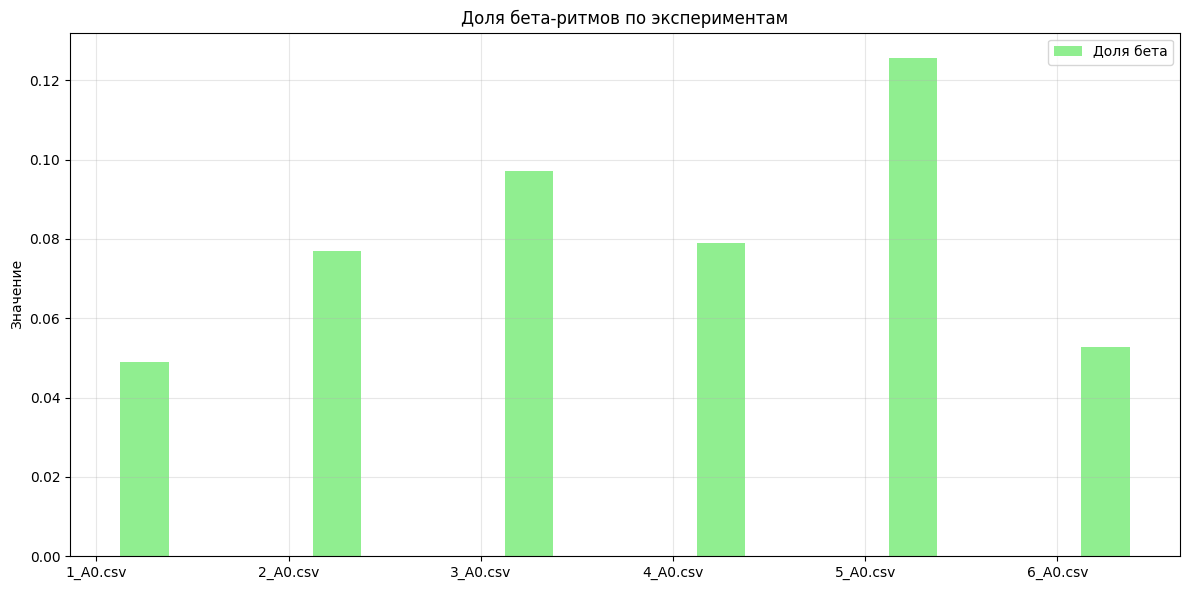

In [ ]:
# Параметры графика
labels = results_df['Файл']
x = np.arange(len(labels))  # позиции для групп
width = 0.25  # ширина столбцов

# Создаём фигуру
plt.figure(figsize=(12, 6))

# Столбцы
plt.bar(x + width, results_df['Доля бета'], width, label='Доля бета', color='lightgreen')

# Подписи
plt.xticks(x, labels)
plt.ylabel("Значение")
plt.title("Доля бета-ритмов по экспериментам")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Вывод

Анализ ЭЭГ показал, что бета-ритмы усиливаются при активной когнитивной нагрузке: решение IQ и алгоритмических задач, шахматы, игра в CS2.

В эксперименте с CS2 наблюдалась наибольшая мощность как альфа-, так и бета-ритмов, что указывает на одновременную высокую концентрацию и активность мозга. Доля бета относительно общей мощности спектра была умеренной, что отражает распределение активности между несколькими ритмами (стресс, внимание, моторика).

Временные показатели (среднее напряжение, стандартное отклонение) стабильны, подтверждая корректность регистрации данных. Результаты соответствуют теоретическим ожиданиям: бета связаны с вниманием и когнитивной активностью, альфа — с концентрацией и сенсорной фильтрацией.


| Эксперимент                             | Средняя мощность бета | Доля бета-ритмов | Краткая интерпретация                                                                |
| --------------------------------------- | --------------------- | ---------------- | ------------------------------------------------------------------------------------ |
| 1. Закрытые глаза, рок-музыка           | средняя                | низкая           | Пассивное состояние, мозг расслаблен, минимальная когнитивная нагрузка               |
| 2. Закрытые глаза, воспроизведение пути | низкая                | средняя          | Визуализация без активного решения задач, умеренная концентрация                     |
| 3. Решение IQ тестов                    | высокая               | высокая          | Повышенная когнитивная активность, внимание и логическое мышление                    |
| 4. Решение алгоритмических задач        | высокая               | средняя          | Активная работа мозга, концентрация на логике и решении задач                        |
| 5. Игра в шахматы                       | средняя               | очень высокая          | Высокая когнитивная нагрузка, стратегическое мышление, внимание                      |
| 6. Игра в CS2                           | очень высокая         | низкая        | Одновременная концентрация, внимание, моторная активность, мульти-режим работы мозга |
